# Sports Image Classification – PyTorch CNN Experiments

This notebook trains and evaluates a **CNN classifier** for sports image classification using **PyTorch**. If a compatible NVIDIA GPU is available, training will run on **CUDA** automatically.

The EDA notebook stays separate; this notebook only covers loading data, training, experiment comparison, and evaluation.

In [1]:
# Imports and environment setup
from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid", context="notebook")

# Make sure both Projekt1 and Projekt2 packages are importable
PROJECT1_ROOT = Path("Projekt1").resolve()
PROJECT2_ROOT = Path("Projekt2").resolve()
for root in [PROJECT1_ROOT, PROJECT2_ROOT]:
    if str(root) not in sys.path:
        sys.path.append(str(root))

from sports_src.data import ImagePreprocessingConfig, load_sports_dataset
from sports_src.experiments import ExperimentConfig, run_experiment
from sports_src.visualization import plot_training_curves, plot_confusion

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU


## 1) Configure Dataset Root

Use the same dataset root that was used in the EDA notebook. The code supports either a KaggleHub download or a local folder with class subdirectories.

In [2]:
# Dataset root configuration
USE_KAGGLEHUB = True
DATASET_SLUG = "gpiosenka/sports-classification"
LOCAL_DATASET_DIR = Path("sports")

if USE_KAGGLEHUB:
    import kagglehub
    dataset_root = Path(kagglehub.dataset_download(DATASET_SLUG)).resolve()
else:
    dataset_root = LOCAL_DATASET_DIR.resolve()

print("Dataset root:", dataset_root)
if not dataset_root.exists():
    raise FileNotFoundError(f"Dataset root does not exist: {dataset_root}")

Dataset root: C:\Users\tisov\.cache\kagglehub\datasets\gpiosenka\sports-classification\versions\9


## 2) Load Dataset and Prepare DataLoaders

We resize images, convert them to RGB tensors, normalize them using train statistics, and create stratified train/validation/test splits. Augmentations are applied only to the training split.

In [3]:
data_config = ImagePreprocessingConfig(
    image_size=(128, 128),
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=RANDOM_SEED,
    max_classes=None,
    max_images_per_class=None,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    augment=True,
)

data = load_sports_dataset(dataset_root, config=data_config)

train_loader = data["train_loader"]
val_loader = data["val_loader"]
test_loader = data["test_loader"]
class_names = [data["idx_to_label"][i] for i in sorted(data["idx_to_label"].keys())]

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("Classes:", class_names)

Train batches: 159
Val batches: 34
Test batches: 34
Classes: ['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling', 'bike polo', 'billiards', 'bmx', 'bobsled', 'bowling', 'boxing', 'bull riding', 'bungee jumping', 'canoe slamon', 'cheerleading', 'chuckwagon racing', 'cricket', 'croquet', 'curling', 'disc golf', 'fencing', 'field hockey', 'figure skating men', 'figure skating pairs', 'figure skating women', 'fly fishing', 'football', 'formula 1 racing', 'frisbee', 'gaga', 'giant slalom', 'golf', 'hammer throw', 'hang gliding', 'harness racing', 'high jump', 'hockey', 'horse jumping', 'horse racing', 'horseshoe pitching', 'hurdles', 'hydroplane racing', 'ice climbing', 'ice yachting', 'jai alai', 'javelin', 'jousting', 'judo', 'lacrosse', 'log rolling', 'luge', 'motorcycle racing', 'mushing', 'nascar racing', 'olympic wrestling', 'parallel bar', 'pole climbing', 'pole dancing', 'pole vault

## 3) Define Experiment Configurations

We compare a few CNN settings to see how depth, regularization and optimizer choice affect validation performance.

In [4]:
experiment_configs = [
    ExperimentConfig(
        name="cnn_baseline",
        dropout=0.2,
        optimizer="adam",
        learning_rate=1e-3,
        epochs=20,
        patience=5,
    ),
    ExperimentConfig(
        name="cnn_stronger_regularization",
        dropout=0.4,
        optimizer="adamw",
        learning_rate=8e-4,
        epochs=25,
        patience=6,
    ),
    ExperimentConfig(
        name="cnn_sgd_momentum",
        dropout=0.3,
        optimizer="sgd",
        learning_rate=5e-3,
        epochs=25,
        patience=6,
    ),
]

experiment_configs

[ExperimentConfig(name='cnn_baseline', dropout=0.2, optimizer='adam', learning_rate=0.001, epochs=20, patience=5, weight_decay=0.0001),
 ExperimentConfig(name='cnn_stronger_regularization', dropout=0.4, optimizer='adamw', learning_rate=0.0008, epochs=25, patience=6, weight_decay=0.0001),
 ExperimentConfig(name='cnn_sgd_momentum', dropout=0.3, optimizer='sgd', learning_rate=0.005, epochs=25, patience=6, weight_decay=0.0001)]

## 4) Run Experiments

Each experiment trains the CNN on the selected device. If CUDA is available, training runs on GPU and uses AMP for faster mixed-precision execution.

In [5]:
results = []

for cfg in experiment_configs:
    res = run_experiment(data, cfg, seed=RANDOM_SEED)
    results.append(res)

summary_rows = []
for res in results:
    cfg = res["config"]
    summary_rows.append({
        "name": cfg.name,
        "dropout": cfg.dropout,
        "optimizer": cfg.optimizer,
        "learning_rate": cfg.learning_rate,
        "epochs": cfg.epochs,
        "val_accuracy": res["val_accuracy"],
        "val_macro_f1": res["val_macro_f1"],
        "test_accuracy": res["test_accuracy"],
        "test_macro_f1": res["test_macro_f1"],
        "device": res["device"],
    })

df_results = pd.DataFrame(summary_rows).sort_values(by="val_macro_f1", ascending=False).reset_index(drop=True)
display(df_results)

Experiment: cnn_baseline
Device: cuda
SportsCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchN

c:\Users\tisov\Počítač\NSIETE-Projekt\Projekt2\sports_src\trainer.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)
c:\Users\tisov\Počítač\NSIETE-Projekt\Projekt2\sports_src\trainer.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):


Epoch 1/20 | train_loss=4.0409 val_loss=3.7141 | train_acc=0.0662 val_acc=0.1030 | train_f1=0.0511 val_f1=0.0561


c:\Users\tisov\Počítač\NSIETE-Projekt\Projekt2\sports_src\trainer.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):


Epoch 2/20 | train_loss=3.5336 val_loss=3.3476 | train_acc=0.1287 val_acc=0.1569 | train_f1=0.1094 val_f1=0.1231


...

Epoch 24/25 | train_loss=2.7247 val_loss=2.5223 | train_acc=0.2886 val_acc=0.3303 | train_f1=0.2674 val_f1=0.2959


c:\Users\tisov\Počítač\NSIETE-Projekt\Projekt2\sports_src\trainer.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):


Epoch 25/25 | train_loss=2.7401 val_loss=2.5250 | train_acc=0.2817 val_acc=0.3316 | train_f1=0.2614 val_f1=0.2963


c:\Users\tisov\Počítač\NSIETE-Projekt\Projekt2\sports_src\trainer.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):
c:\Users\tisov\Počítač\NSIETE-Projekt\Projekt2\sports_src\trainer.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):


,name,dropout,optimizer,learning_rate,epochs,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,device
0,cnn_baseline,0.2,adam,0.0010,20,0.455382,0.434111,0.466421,0.442158,cuda
1,cnn_stronger_regularization,0.4,adamw,0.0008,25,0.414903,0.387682,0.413523,0.384230,cuda
2,cnn_sgd_momentum,0.3,sgd,0.0050,25,0.330267,0.295895,0.339926,0.301870,cuda


## 5) Inspect Best Model

We select the best experiment by validation macro-F1 and inspect training curves, confusion matrix, and class-wise metrics on the test set.

Best experiment: cnn_baseline


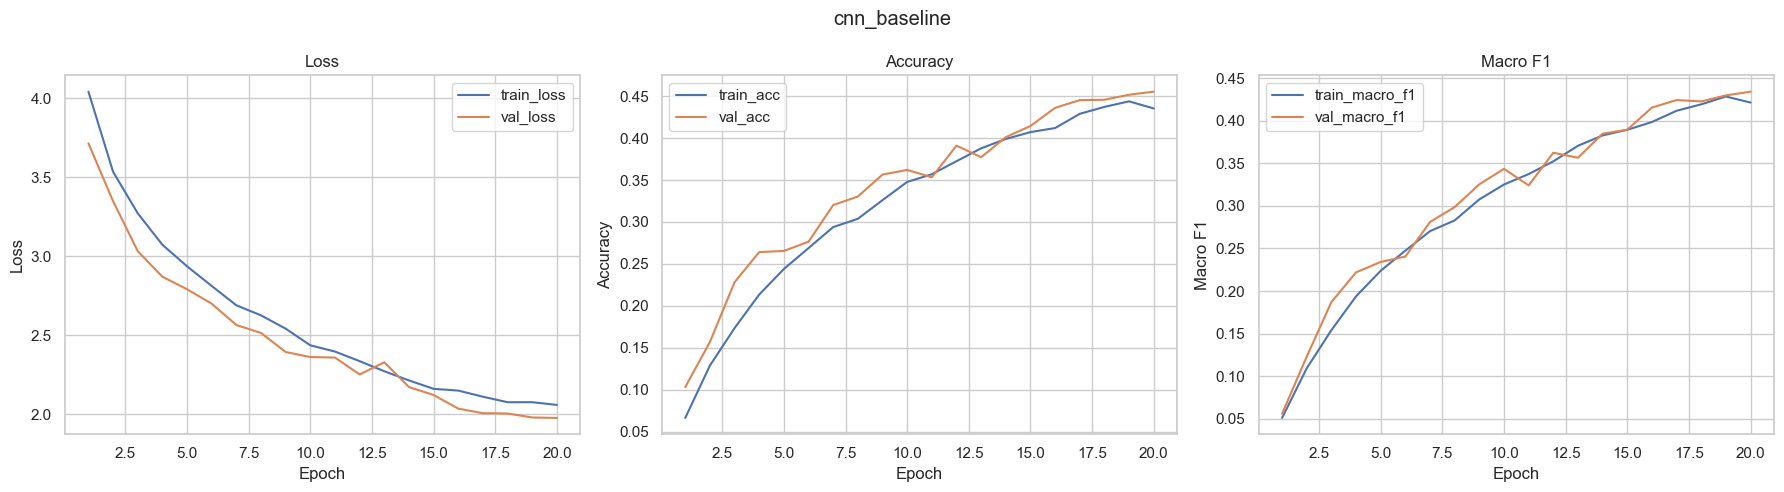

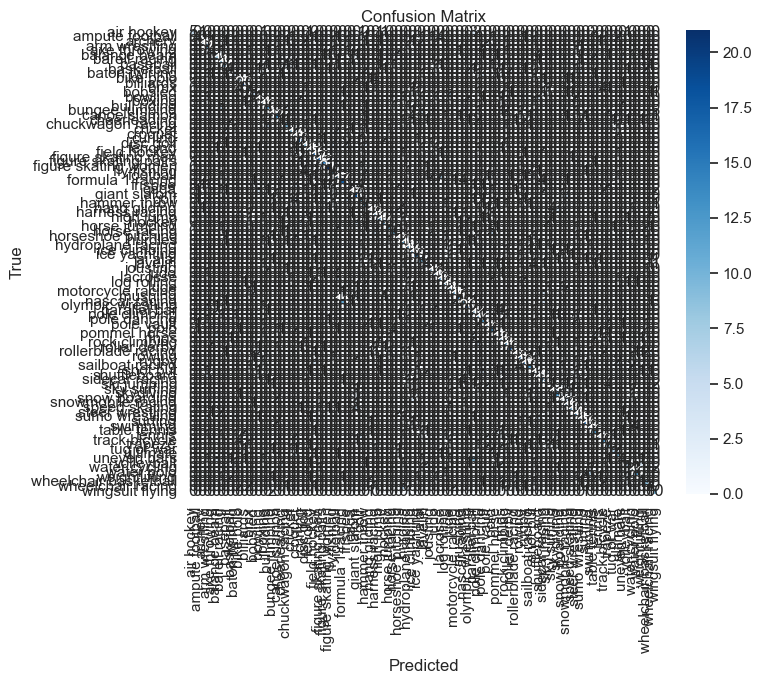

                       precision    recall  f1-score   support

           air hockey       0.62      0.26      0.37        19
      ampute football       0.50      0.21      0.30        19
              archery       0.40      0.09      0.15        22
        arm wrestling       0.38      0.69      0.49        16
         axe throwing       0.44      0.22      0.30        18
         balance beam       0.44      0.33      0.38        24
        barell racing       0.44      0.55      0.49        20
             baseball       0.58      0.52      0.55        27
           basketball       0.40      0.15      0.22        27
       baton twirling       0.38      0.17      0.23        18
            bike polo       0.25      0.33      0.29        18
            billiards       0.74      0.87      0.80        23
                  bmx       0.39      0.32      0.35        22
              bobsled       0.45      0.23      0.30        22
              bowling       0.27      0.20      0.23  

In [6]:
best_name = df_results.iloc[0]["name"]
print("Best experiment:", best_name)

best_run = next(res for res in results if res["config"].name == best_name)
history = best_run["history"]
trainer = best_run["trainer"]

plot_training_curves(history, title=best_name)

y_true, y_pred = trainer.predict(test_loader)
plot_confusion(y_true, y_pred, class_names=class_names)

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0,
))

## 6) Discussion and Conclusions

Write a short discussion here about:

- which CNN configuration worked best,
- whether stronger dropout improved generalization,
- which classes are frequently confused,
- and what you would try next if you had more time (e.g. larger input size, transfer learning, deeper CNN, more augmentation).